**Data Loading and Cleaning**

In [19]:
import pandas as pd
import numpy as np
import glob
import os

folder_path = 'PL_matches'
all_szns = []

if not os.path.exists(folder_path):
    print(f"Error: The folder '{folder_path}' was not found in the current directory.")
else:
    # Files specifically inside that folder
    pl_files = sorted([f for f in os.listdir(folder_path) if f.startswith('PL-') and f.endswith('.csv')])
    all_szns = []

# Concatenation of all season datasets
for file in pl_files: # loop through each file
    try:
        df = pd.read_csv(os.path.join(folder_path, file), encoding='unicode_escape')
        cols = ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF',
                'HC', 'AC', 'HY', 'AY', 'HR', 'AR']
    
        if all(col in df.columns for col in cols): # check if all required columns are present
            df = df[cols].copy()
            df = df.dropna(how='all')
            df = df.dropna(subset=['HomeTeam', 'AwayTeam', 'Date'])
            all_szns.append(df)
        else:
            print(f"Error: Missing columns in file {file}")
    
    except Exception as e:
        print(f"Error processing file {file}: {e}")

if all_szns:    
    pl_df = pd.concat(all_szns, ignore_index=True)
    # Parsing dates
    pl_df['Date'] = pd.to_datetime(pl_df['Date'], dayfirst=True)
    pl_df = pl_df.sort_values(by='Date').reset_index(drop=True)
    print(f"Total number of matches: {len(pl_df)}")
else:
    print("No valid data to process.")

pl_df.head()

Total number of matches: 4560


C:\Users\couga\AppData\Local\Temp\ipykernel_11768\3730318229.py:37: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  pl_df['Date'] = pd.to_datetime(pl_df['Date'], dayfirst=True)


,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,2013-08-17,Arsenal,Aston Villa,1.0,3.0,A,16.0,9.0,4.0,4.0,15.0,18.0,4.0,3.0,4.0,5.0,1.0,0.0
1,2013-08-17,Liverpool,Stoke,1.0,0.0,H,26.0,10.0,11.0,4.0,11.0,11.0,12.0,6.0,1.0,1.0,0.0,0.0
2,2013-08-17,Norwich,Everton,2.0,2.0,D,8.0,19.0,2.0,6.0,13.0,10.0,6.0,8.0,2.0,0.0,0.0,0.0
3,2013-08-17,Sunderland,Fulham,0.0,1.0,A,20.0,5.0,3.0,1.0,14.0,14.0,6.0,1.0,0.0,3.0,0.0,0.0
4,2013-08-17,Swansea,Man United,1.0,4.0,A,17.0,15.0,6.0,7.0,13.0,10.0,7.0,4.0,1.0,3.0,0.0,0.0


**Feature Engineering: ELO, Clinicalness in front of goal, Form, Rest Days**

In [20]:
# Elo Rating System Implementation
team_elos = {}
init_elo = 1500 # starting Elo rating for new teams
all_clubs = set(pl_df['HomeTeam'].unique()).union(set(pl_df['AwayTeam'].unique()))
for club in all_clubs:
    team_elos[club] = init_elo
k_factor = 20 # sensitivity factor for Elo updates
elo_home = []
elo_away = []
print("Loading Elo Ratings...")

for index, row in pl_df.iterrows():
    h_team = row['HomeTeam']
    a_team = row['AwayTeam']
    h_elo = team_elos.get(h_team, init_elo) # get home team Elo, default to init_elo otherwise
    a_elo = team_elos.get(a_team, init_elo) # get away team Elo, default to init_elo otherwise
    # Storing current Elo ratings
    elo_home.append(h_elo)
    elo_away.append(a_elo)
    # Expected result calculation: 1 / (1 + 10^((opponent_elo - team_elo)/400))
    dr = h_elo - a_elo + 100 # +100 adds home advantage
    e_home = 1 / (1 + 10**(-dr / 400)) # expected score for home team

    # Actual result
    if row['FTR'] == 'H':
        s_home = 1.0
    elif row['FTR'] == 'D':
        s_home = 0.5
    else:
        s_home = 0.0
    
    # Elo rating updates
    team_elos[h_team] = h_elo + k_factor * (s_home - e_home)
    team_elos[a_team] = a_elo + k_factor * ((1 - s_home) - (1 - e_home))

# Adding Elo ratings to dataframe
pl_df['HomeElo'] = elo_home
pl_df['AwayElo'] = elo_away
print("Elo Ratings Loaded.")

# Prepping the data for rolling averages (form over last 5 matches)
def get_team_stats(matches):
    # Home team stats
    home_df = matches[['Date', 'HomeTeam', 'FTHG', 'FTAG', 'FTR', 'HS', 'HST']].copy()
    home_df.columns = ['Date', 'Team', 'GoalsFor', 'GoalsAgainst', 'Result', 'Shots', 'ShotsTarget']
    home_df['IsHome'] = 1
    home_df['Points'] = home_df['Result'].map({'H': 3, 'D': 1, 'A': 0})
    # Away team stats
    away_df = matches[['Date', 'AwayTeam', 'FTAG', 'FTHG', 'FTR', 'AS', 'AST']].copy()
    away_df.columns = ['Date', 'Team', 'GoalsFor', 'GoalsAgainst', 'Result', 'Shots', 'ShotsTarget']
    away_df['IsHome'] = 0
    away_df['Points'] = away_df['Result'].map({'A': 3, 'D': 1, 'H': 0})
    # Combine home and away stats and sort
    return pd.concat([home_df, away_df], ignore_index=True).sort_values(by='Date')
team_stats = get_team_stats(pl_df)

print("Loading Rolling Averages (Form over last 5 matches)...")

metrics = ['GoalsFor', 'GoalsAgainst', 'Points', 'Shots', 'ShotsTarget']

rolling_stats = team_stats.groupby('Team')[metrics].apply(lambda x: x.shift(1).rolling(window=5, min_periods=3).mean()) # .shift(1) to avoid data leakage
rolling_stats.columns = [f'Roll5_{col}' for col in rolling_stats.columns]

if isinstance(rolling_stats.index, pd.MultiIndex):
    rolling_stats = rolling_stats.reset_index(level=0, drop=True)
    
team_stats = pd.concat([team_stats, rolling_stats], axis=1) # merge rolling stats back to team_stats

# Clinicalness (Shots on Target / Shots)
team_stats['Roll5_ShotAcc'] = team_stats['Roll5_ShotsTarget'] / team_stats['Roll5_Shots']
team_stats['Roll5_ShotAcc'] = team_stats['Roll5_ShotAcc'].fillna(0) # for cases with 0 shots

# Fatigue (Days since last match)
team_stats['PrevMatchDate'] = team_stats.groupby('Team')['Date'].shift(1)
team_stats['RestDays'] = (team_stats['Date'] - team_stats['PrevMatchDate']).dt.days
team_stats['RestDays'] = team_stats['RestDays'].fillna(7) # assume 7 days rest if no previous match
print("Rolling Averages Loaded.")

# Merge back to main dataframe
print("Merging and Finalizing...")

team_stats = team_stats.dropna(subset=['Roll5_Points']) # drop rows where rolling stats are NaN
cols_to_merge = ['Date', 'Team', 'RestDays', 'Roll5_Points', 'Roll5_GoalsFor', 'Roll5_GoalsAgainst', 'Roll5_ShotAcc']
home_stats = team_stats[team_stats['IsHome'] == 1][cols_to_merge]
home_stats.columns = ['Date', 'HomeTeam', 'HomeRestDays', 'HomeForm', 'HomeAttack', 'HomeDefense', 'HomeShotAcc']
away_stats = team_stats[team_stats['IsHome'] == 0][cols_to_merge]
away_stats.columns = ['Date', 'AwayTeam', 'AwayRestDays', 'AwayForm', 'AwayAttack', 'AwayDefense', 'AwayShotAcc']

# Merging home and away stats
final_df = pd.merge(pl_df, home_stats, on=['Date', 'HomeTeam'], how='inner')
final_df = pd.merge(final_df, away_stats, on=['Date', 'AwayTeam'], how='inner')
final_df['Target'] = final_df['FTR'].map({'H': 0, 'D': 1, 'A': 2}) # Target variable; 0=Home Win, 1=Draw, 2=Away Win
final_cols = ['Date', 'HomeTeam', 'AwayTeam', 'FTR', 'Target', 'HomeElo', 'AwayElo', 'HomeForm', 'AwayForm', 
              'HomeRestDays', 'AwayRestDays', 'HomeShotAcc', 'AwayShotAcc', 'HomeAttack', 'AwayAttack', 
              'HomeDefense', 'AwayDefense']
final_df = final_df[final_cols]
print("Merging and Finalizing Completed.")
print(f"Shape of final dataset: {final_df.shape}")
print(final_df.head())

Loading Elo Ratings...
Elo Ratings Loaded.
Loading Rolling Averages (Form over last 5 matches)...
Rolling Averages Loaded.
Merging and Finalizing...
Merging and Finalizing Completed.
Shape of final dataset: (4485, 17)
        Date    HomeTeam        AwayTeam FTR  Target      HomeElo  \
0 2013-09-14       Stoke        Man City   D       1  1512.910209   
1 2013-09-14   Tottenham         Norwich   H       0  1511.634816   
2 2013-09-14  Man United  Crystal Palace   H       0  1503.108283   
3 2013-09-14  Sunderland         Arsenal   A       2  1483.184235   
4 2013-09-14      Fulham       West Brom   D       1  1491.898085   

       AwayElo  HomeForm  AwayForm  HomeRestDays  AwayRestDays  HomeShotAcc  \
0  1506.825918  2.000000  2.000000          14.0          14.0     0.358974   
1  1497.605284  2.000000  1.333333          13.0          14.0     0.220000   
2  1487.627849  1.333333  1.000000          13.0          14.0     0.368421   
3  1508.365184  0.333333  2.000000          14.0   

Data Scaled. Mean of first feature: 0.00, Std: 1.00


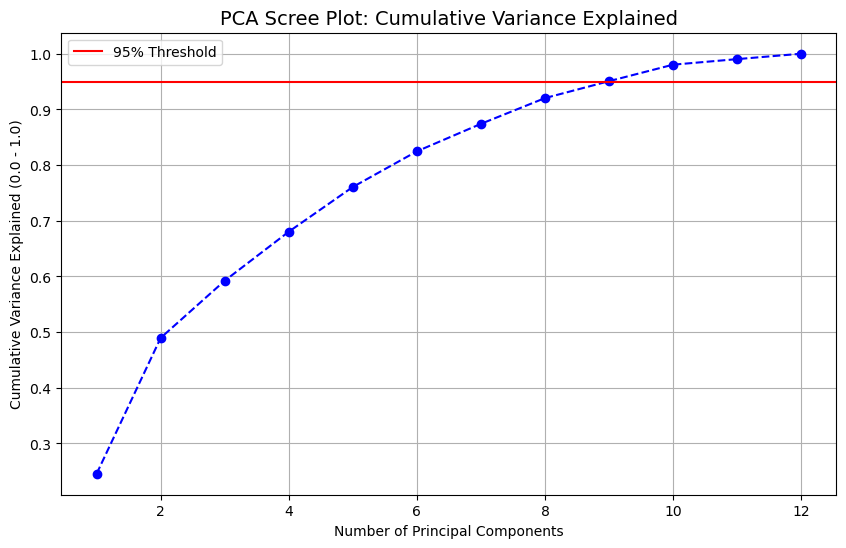

Number of components needed to explain 95% variance: 9


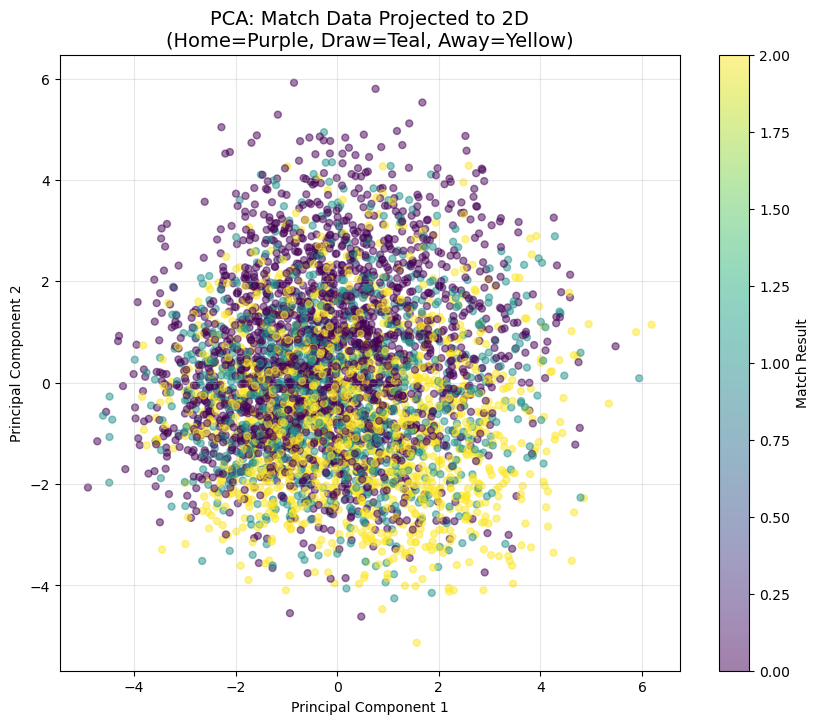

Running ISOMAP on a sample of 1000 points (for visualization only)...


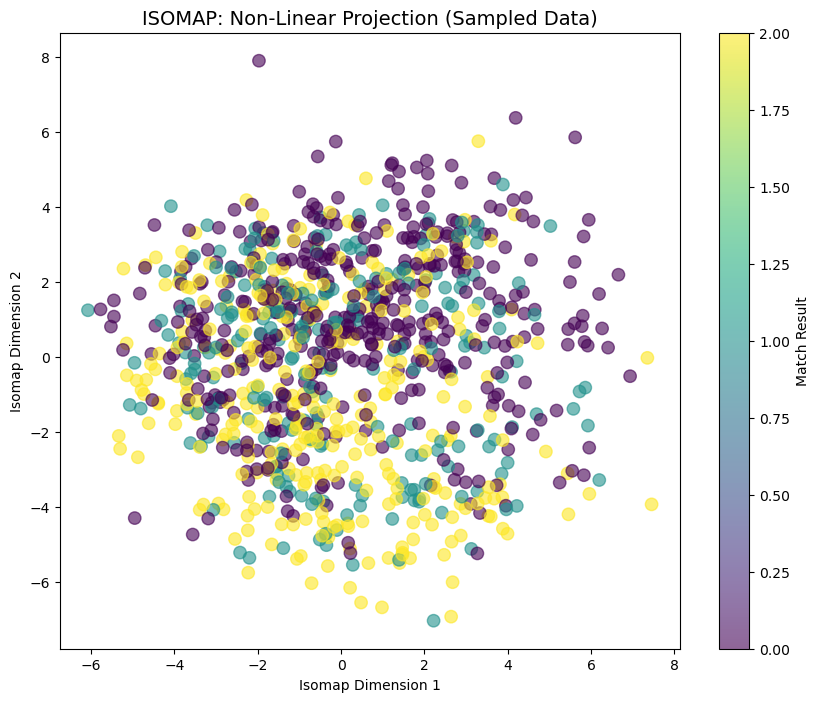

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import Isomap
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PREPARE DATA ---
# Define the feature columns (Exclude Date, Teams, Target)
feature_cols = ['HomeElo', 'AwayElo', 
                'HomeForm', 'AwayForm', 
                'HomeRestDays', 'AwayRestDays',
                'HomeShotAcc', 'AwayShotAcc', 
                'HomeAttack', 'AwayAttack', 
                'HomeDefense', 'AwayDefense']

X = final_df[feature_cols]
y = final_df['Target']  # 0=Home, 1=Draw, 2=Away

# Check for NaNs (just in case)
if X.isnull().values.any():
    print("Warning: NaNs found. Filling with mean...")
    X = X.fillna(X.mean())

# --- 2. STANDARDIZATION ---
# Critical for PCA: Features must be on the same scale (e.g. Elo is 1500, Form is 1.5)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data Scaled. Mean of first feature: {:.2f}, Std: {:.2f}".format(
    X_scaled[:, 0].mean(), X_scaled[:, 0].std()))


# --- 3. PCA ANALYSIS (The "Scree Plot") ---
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate Cumulative Variance Explained
cum_var = np.cumsum(pca.explained_variance_ratio_)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker='o', linestyle='--', color='b')
plt.title('PCA Scree Plot: Cumulative Variance Explained', fontsize=14)
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained (0.0 - 1.0)')
plt.axhline(y=0.95, color='r', linestyle='-', label='95% Threshold')
plt.grid(True)
plt.legend()
plt.show()

# Find exact number of components for 95% variance
n_components_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Number of components needed to explain 95% variance: {n_components_95}")


# --- 4. VISUALIZATION: 2D PROJECTION ---
# Let's see if the classes separate in 2D space
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.5, s=25)
plt.title(f'PCA: Match Data Projected to 2D\n(Home=Purple, Draw=Teal, Away=Yellow)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Match Result')
plt.grid(True, alpha=0.3)
plt.show()

# --- 5. ISOMAP (Non-Linear Manifold - Creativity Check) ---
# ISOMAP is computationally expensive O(N^2). We will run it on a SAMPLE of the data.
print("Running ISOMAP on a sample of 1000 points (for visualization only)...")
sample_idx = np.random.choice(X_scaled.shape[0], 1000, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y.iloc[sample_idx]

iso = Isomap(n_neighbors=15, n_components=2)
X_iso = iso.fit_transform(X_sample)

plt.figure(figsize=(10, 8))
scatter_iso = plt.scatter(X_iso[:, 0], X_iso[:, 1], c=y_sample, cmap='viridis', alpha=0.6, s=80)
plt.title('ISOMAP: Non-Linear Projection (Sampled Data)', fontsize=14)
plt.xlabel('Isomap Dimension 1')
plt.ylabel('Isomap Dimension 2')
plt.colorbar(scatter_iso, label='Match Result')
plt.show()